In [271]:
import matplotlib.pyplot as plt
import scipy.stats as st
import pandas as pd


In [139]:
# Reading in CSVs will take a bit longer since we're reading in 8 data sets

dailyActivity = pd.read_csv("dailyActivity_merged.csv")
heartRateSeconds = pd.read_csv("heartrate_seconds_merged.csv")
hourlyCalories = pd.read_csv("hourlyCalories_merged.csv")
hourlyIntensities = pd.read_csv("hourlyIntensities_merged.csv")
hourlySteps = pd.read_csv("hourlySteps_merged.csv")
minuteCalories = pd.read_csv("minuteCaloriesNarrow_merged.csv")
minuteIntensities = pd.read_csv("minuteIntensitiesNarrow_merged.csv")
minuteMETs = pd.read_csv("minuteMETsNarrow_merged.csv")
sleepDay = pd.read_csv("sleepDay_merged.csv")
weightLogInfo = pd.read_csv("weightLogInfo_merged.csv")

`Part 2 (Starting with this will make the other tasks simpler)`

**Combining Hourly Data and creating Hourly Dataset (expect time delay in following cell)**

In [5]:
hourlySteps["ActivityHour"] = pd.to_datetime(hourlySteps["ActivityHour"])
hourlyIntensities["ActivityHour"] = pd.to_datetime(hourlyIntensities["ActivityHour"])
hourlyCalories["ActivityHour"] = pd.to_datetime(hourlyCalories["ActivityHour"])

/var/folders/fm/1rc1d6s92qg_dtmxcn1__h1r0000gn/T/ipykernel_14240/4271826423.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourlySteps["ActivityHour"] = pd.to_datetime(hourlySteps["ActivityHour"])
/var/folders/fm/1rc1d6s92qg_dtmxcn1__h1r0000gn/T/ipykernel_14240/4271826423.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourlyIntensities["ActivityHour"] = pd.to_datetime(hourlyIntensities["ActivityHour"])
/var/folders/fm/1rc1d6s92qg_dtmxcn1__h1r0000gn/T/ipykernel_14240/4271826423.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourlyCalories["ActivityHour"] = pd.

In [204]:
hourly = hourlySteps.merge(hourlyIntensities, on=["Id", "ActivityHour"], how="inner")


In [205]:
hourly = hourly.merge(hourlyCalories, on=["Id", "ActivityHour"], how="inner")

In [206]:
print(hourly.head())

           Id           ActivityHour  StepTotal  TotalIntensity  \
0  1503960366  4/12/2016 12:00:00 AM        373              20   
1  1503960366   4/12/2016 1:00:00 AM        160               8   
2  1503960366   4/12/2016 2:00:00 AM        151               7   
3  1503960366   4/12/2016 3:00:00 AM          0               0   
4  1503960366   4/12/2016 4:00:00 AM          0               0   

   AverageIntensity  Calories  
0          0.333333        81  
1          0.133333        61  
2          0.116667        59  
3          0.000000        47  
4          0.000000        48  


**Combining Minute data and creating Minutely Dataset (expect delay in the following cell)**

In [233]:
# This cell if the previous cells compiled for your IDE will still take long
# in my runs and testing, it took 3 minutes and a 20s, but it might be faster or slower for you
minuteCalories["ActivityMinute"] = pd.to_datetime(minuteCalories["ActivityMinute"])
minuteIntensities["ActivityMinute"] = pd.to_datetime(minuteIntensities["ActivityMinute"])
minuteMETs["ActivityMinute"] = pd.to_datetime(minuteMETs["ActivityMinute"])

/var/folders/fm/1rc1d6s92qg_dtmxcn1__h1r0000gn/T/ipykernel_14240/1420932168.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  minuteCalories["ActivityMinute"] = pd.to_datetime(minuteCalories["ActivityMinute"])
/var/folders/fm/1rc1d6s92qg_dtmxcn1__h1r0000gn/T/ipykernel_14240/1420932168.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  minuteIntensities["ActivityMinute"] = pd.to_datetime(minuteIntensities["ActivityMinute"])
/var/folders/fm/1rc1d6s92qg_dtmxcn1__h1r0000gn/T/ipykernel_14240/1420932168.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  minuteMETs["ActivityMi

In [234]:
minutely = minuteCalories.merge(minuteIntensities, on=["Id", "ActivityMinute"], how="inner")

In [235]:
minutely = minutely.merge(minuteMETs, on=["Id", "ActivityMinute"], how="inner")

In [236]:
print(minutely.head())

           Id      ActivityMinute  Calories  Intensity  METs
0  1503960366 2016-04-12 00:00:00    0.7865          0    10
1  1503960366 2016-04-12 00:01:00    0.7865          0    10
2  1503960366 2016-04-12 00:02:00    0.7865          0    10
3  1503960366 2016-04-12 00:03:00    0.7865          0    10
4  1503960366 2016-04-12 00:04:00    0.7865          0    10


**Standardizing the datetime for the Required Datasets to include a Date column**

In [210]:
dailyActivity["Date"] = pd.to_datetime(dailyActivity["ActivityDate"]).dt.date

In [211]:
sleepDay["Date"] = pd.to_datetime(sleepDay["SleepDay"]).dt.date

/var/folders/fm/1rc1d6s92qg_dtmxcn1__h1r0000gn/T/ipykernel_14240/734943722.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleepDay["Date"] = pd.to_datetime(sleepDay["SleepDay"]).dt.date


In [247]:
hourly["Date"] = pd.to_datetime(hourly["ActivityHour"])

/var/folders/fm/1rc1d6s92qg_dtmxcn1__h1r0000gn/T/ipykernel_14240/3908704710.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly["Date"] = pd.to_datetime(hourly["ActivityHour"])


In [237]:
minutely["Date"] = pd.to_datetime(minutely["ActivityMinute"])

In [214]:
dailyActivity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Date
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2016-04-13
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,2016-04-14
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,2016-04-15
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2016-04-16


In [215]:
sleepDay.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,Date
0,1503960366,4/12/2016 12:00:00 AM,1,327,346,2016-04-12
1,1503960366,4/13/2016 12:00:00 AM,2,384,407,2016-04-13
2,1503960366,4/15/2016 12:00:00 AM,1,412,442,2016-04-15
3,1503960366,4/16/2016 12:00:00 AM,2,340,367,2016-04-16
4,1503960366,4/17/2016 12:00:00 AM,1,700,712,2016-04-17


In [238]:
minutely.head()

,Id,ActivityMinute,Calories,Intensity,METs,Date
0,1503960366,2016-04-12 00:00:00,0.7865,0,10,2016-04-12 00:00:00
1,1503960366,2016-04-12 00:01:00,0.7865,0,10,2016-04-12 00:01:00
2,1503960366,2016-04-12 00:02:00,0.7865,0,10,2016-04-12 00:02:00
3,1503960366,2016-04-12 00:03:00,0.7865,0,10,2016-04-12 00:03:00
4,1503960366,2016-04-12 00:04:00,0.7865,0,10,2016-04-12 00:04:00


In [248]:
hourly.head()

,Id,ActivityHour,StepTotal,TotalIntensity,AverageIntensity,Calories,Date
0,1503960366,4/12/2016 12:00:00 AM,373,20,0.333333,81,2016-04-12 00:00:00
1,1503960366,4/12/2016 1:00:00 AM,160,8,0.133333,61,2016-04-12 01:00:00
2,1503960366,4/12/2016 2:00:00 AM,151,7,0.116667,59,2016-04-12 02:00:00
3,1503960366,4/12/2016 3:00:00 AM,0,0,0.000000,47,2016-04-12 03:00:00
4,1503960366,4/12/2016 4:00:00 AM,0,0,0.000000,48,2016-04-12 04:00:00


**HeartRate per minute inclusion into the minutely dataset**

In [239]:
heartRateSeconds["Time"] = pd.to_datetime(heartRateSeconds["Time"])

In [240]:
# This should make it so every 5 seconds intervals you see, it'll make it so the time
# reads the same, e.g. 12:01:05, 12:01:10, 12:01:55 → 12:01:00
heartRateSeconds["ActivityMinute"] = heartRateSeconds["Time"].dt.floor("min")

In [241]:
heartrate_minute = (heartRateSeconds.groupby(["Id", "ActivityMinute"])["Value"].mean().reset_index())

In [242]:
heartrate_minute = heartrate_minute.rename(columns={"Value": "AvgHeartRate"})

In [243]:
#Value is the Average Heart Rate per minute
heartrate_minute.head()

,Id,ActivityMinute,AvgHeartRate
0,2022484408,2016-04-12 07:21:00,101.600000
1,2022484408,2016-04-12 07:22:00,87.888889
2,2022484408,2016-04-12 07:23:00,58.000000
3,2022484408,2016-04-12 07:24:00,58.000000
4,2022484408,2016-04-12 07:25:00,56.777778


In [244]:
minutely.head()

,Id,ActivityMinute,Calories,Intensity,METs,Date
0,1503960366,2016-04-12 00:00:00,0.7865,0,10,2016-04-12 00:00:00
1,1503960366,2016-04-12 00:01:00,0.7865,0,10,2016-04-12 00:01:00
2,1503960366,2016-04-12 00:02:00,0.7865,0,10,2016-04-12 00:02:00
3,1503960366,2016-04-12 00:03:00,0.7865,0,10,2016-04-12 00:03:00
4,1503960366,2016-04-12 00:04:00,0.7865,0,10,2016-04-12 00:04:00


In [249]:
# Inner is because this new data set is based around heart rate
minutelyheart = minutely.merge(heartrate_minute, on=["Id", "ActivityMinute"], how="inner")

In [251]:
# just to see it got merged with values
print(minutelyheart.head())

           Id      ActivityMinute  Calories  Intensity  METs  \
0  2022484408 2016-04-12 07:21:00   3.32064          1    32   
1  2022484408 2016-04-12 07:22:00   3.94326          1    38   
2  2022484408 2016-04-12 07:23:00   1.34901          0    13   
3  2022484408 2016-04-12 07:24:00   1.03770          0    10   
4  2022484408 2016-04-12 07:25:00   1.03770          0    10   

                 Date  AvgHeartRate  
0 2016-04-12 07:21:00    101.600000  
1 2016-04-12 07:22:00     87.888889  
2 2016-04-12 07:23:00     58.000000  
3 2016-04-12 07:24:00     58.000000  
4 2016-04-12 07:25:00     56.777778  


**Plotting the Graphs**

`Part 3 Graphs`

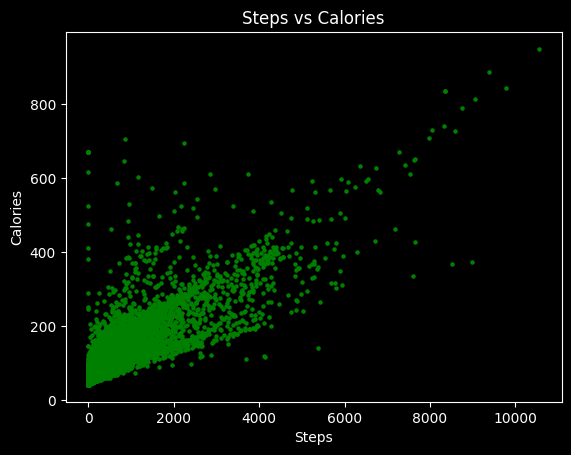

In [285]:
#Part 3-1a

plt.scatter(hourly["StepTotal"], hourly["Calories"], s=5, color = 'green')
plt.xlabel("Steps")
plt.ylabel("Calories")
plt.title("Steps vs Calories")
plt.show()

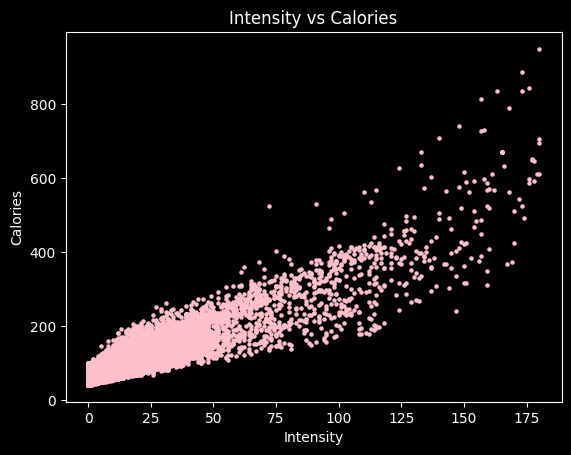

In [286]:
# for part 3-1b

plt.scatter(hourly["TotalIntensity"], hourly["Calories"], s=5, color = 'pink')
plt.xlabel("Intensity")
plt.ylabel("Calories")
plt.title("Intensity vs Calories")
plt.show()

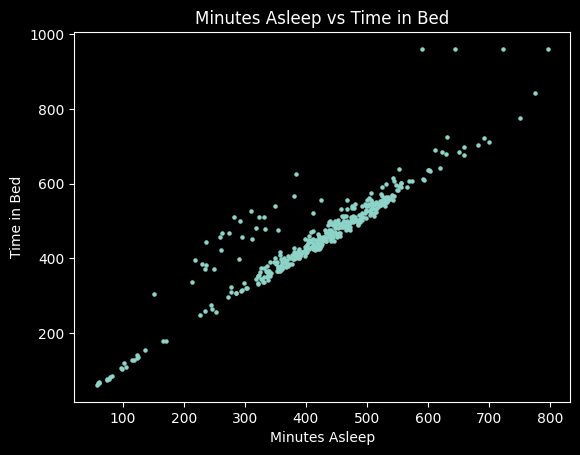

In [287]:
# Part 3-2

plt.scatter(sleepDay["TotalMinutesAsleep"], sleepDay["TotalTimeInBed"], s = 5)
plt.xlabel("Minutes Asleep")
plt.ylabel("Time in Bed")
plt.title("Minutes Asleep vs Time in Bed")
plt.show()

In [316]:
# Part 3-4
merged = pd.merge(sleepDay, dailyActivity, on=["Id", "Date"], how="inner")
print(merged.head())

           Id               SleepDay  TotalSleepRecords  TotalMinutesAsleep  \
0  1503960366  4/12/2016 12:00:00 AM                  1                 327   
1  1503960366  4/13/2016 12:00:00 AM                  2                 384   
2  1503960366  4/15/2016 12:00:00 AM                  1                 412   
3  1503960366  4/16/2016 12:00:00 AM                  2                 340   
4  1503960366  4/17/2016 12:00:00 AM                  1                 700   

   TotalTimeInBed        Date ActivityDate  TotalSteps  TotalDistance  \
0             346  2016-04-12    4/12/2016       13162           8.50   
1             407  2016-04-13    4/13/2016       10735           6.97   
2             442  2016-04-15    4/15/2016        9762           6.28   
3             367  2016-04-16    4/16/2016       12669           8.16   
4             712  2016-04-17    4/17/2016        9705           6.48   

   TrackerDistance  LoggedActivitiesDistance  VeryActiveDistance  \
0             8.50

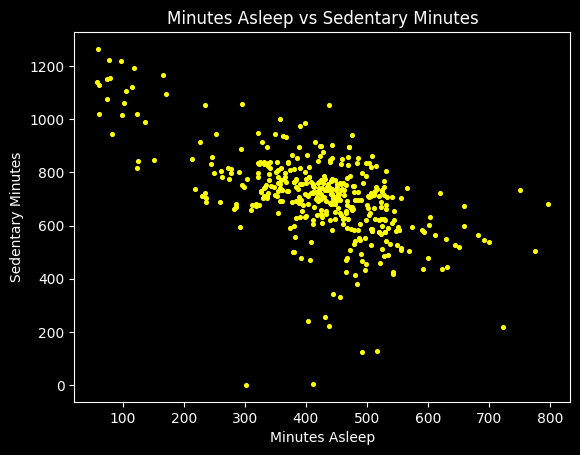

In [301]:
plt.scatter(merged["TotalMinutesAsleep"], merged["SedentaryMinutes"], s =7, color = 'yellow')
plt.xlabel("Minutes Asleep")
plt.ylabel("Sedentary Minutes")
plt.title("Minutes Asleep vs Sedentary Minutes")
plt.show()

In [136]:
# Part 3-3
hourly["Hour"] = hourly["ActivityHour"].dt.hour

# Some Arbitrary Day Picked
one_day = hourly[hourly["ActivityHour"].dt.date == hourly["ActivityHour"].dt.date.iloc[0]]

In [137]:
users = one_day["Id"].unique()[:5]

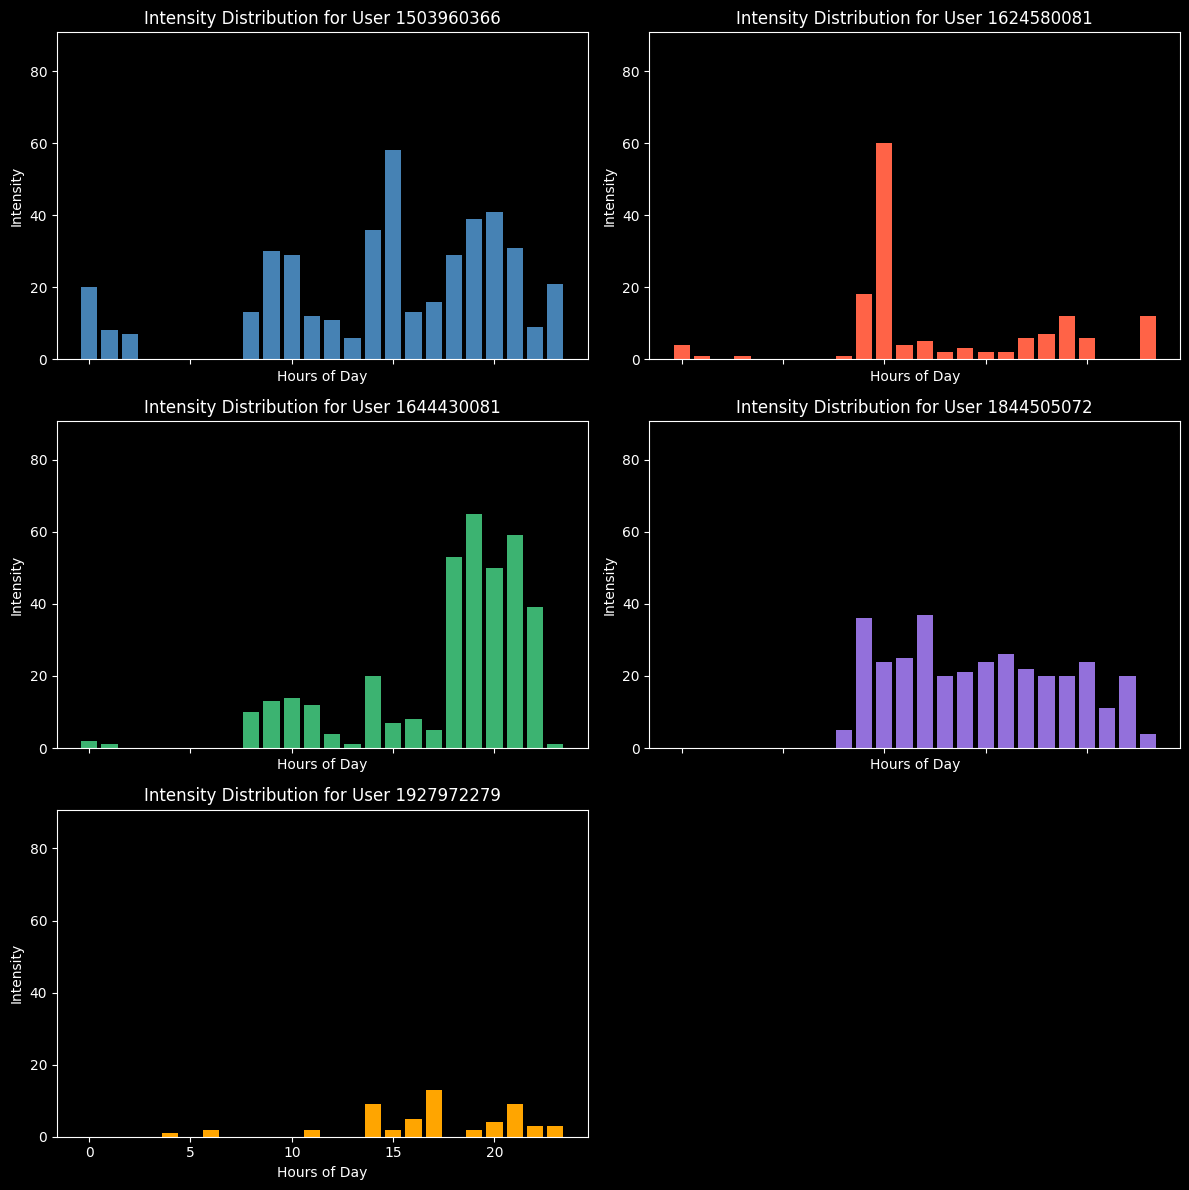

In [314]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)
axes = axes.flatten()

colors = ['steelblue', 'tomato', 'mediumseagreen', 'mediumpurple', 'orange']

for i, u in enumerate(users):
    subset = one_day[one_day["Id"] == u]
    axes[i].bar(subset["Hour"], subset["TotalIntensity"], color=colors[i])
    axes[i].set_xlabel("Hours of Day")
    axes[i].set_ylabel("Intensity")
    axes[i].set_title(f"Intensity Distribution for User {u}")
    axes[i].set_ylim(0, one_day["TotalIntensity"].max() * 0.55)

axes[5].set_visible(False)

plt.tight_layout()
plt.show()

`Part 1 Graphs (Not in Chronological Order, but is Labelled)`

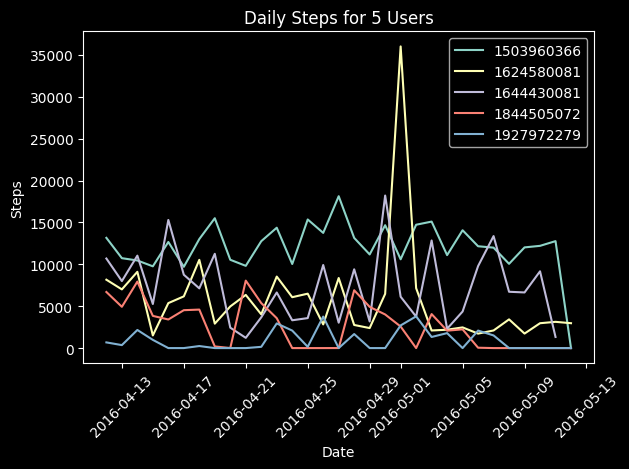

In [279]:
# Part 1-c

users = dailyActivity["Id"].unique()[:5]

for u in users:
    subset = dailyActivity[dailyActivity["Id"] == u]
    #print(subset)
    plt.plot(subset["Date"], subset["TotalSteps"], label=str(u))

plt.legend()
plt.xlabel("Date")
plt.ylabel("Steps")
plt.title("Daily Steps for 5 Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

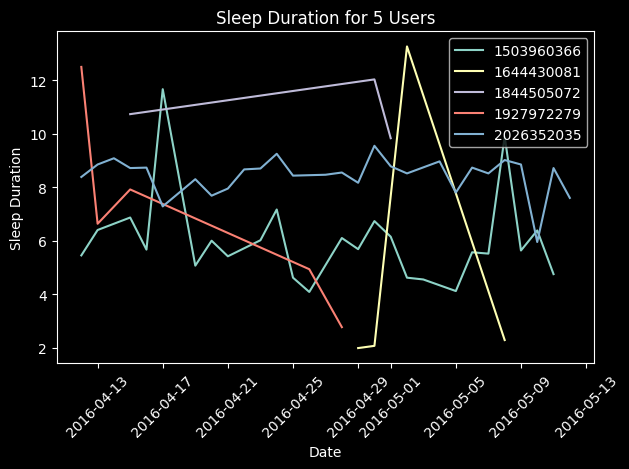

In [273]:
# Part 1-b

users = sleepDay["Id"].unique()[:5]

for u in users:
    subset = sleepDay[sleepDay["Id"] == u]
    #print(subset)
    plt.plot(subset["Date"], subset["TotalMinutesAsleep"] / 60, label=str(u))

plt.legend()
plt.xlabel("Date")
plt.ylabel("Sleep Duration")
plt.title("Sleep Duration for 5 Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [253]:
# Part 1-a

five_users = heartRateSeconds["Id"].unique()[:5]
hr_5 = heartRateSeconds[heartRateSeconds["Id"].isin(five_users)]

In [254]:
hr_daily = hr_5.groupby(["Id", hr_5["Time"].dt.date])["Value"].mean().reset_index()
hr_daily.columns = ["Id", "Date", "AvgHeartRate"]

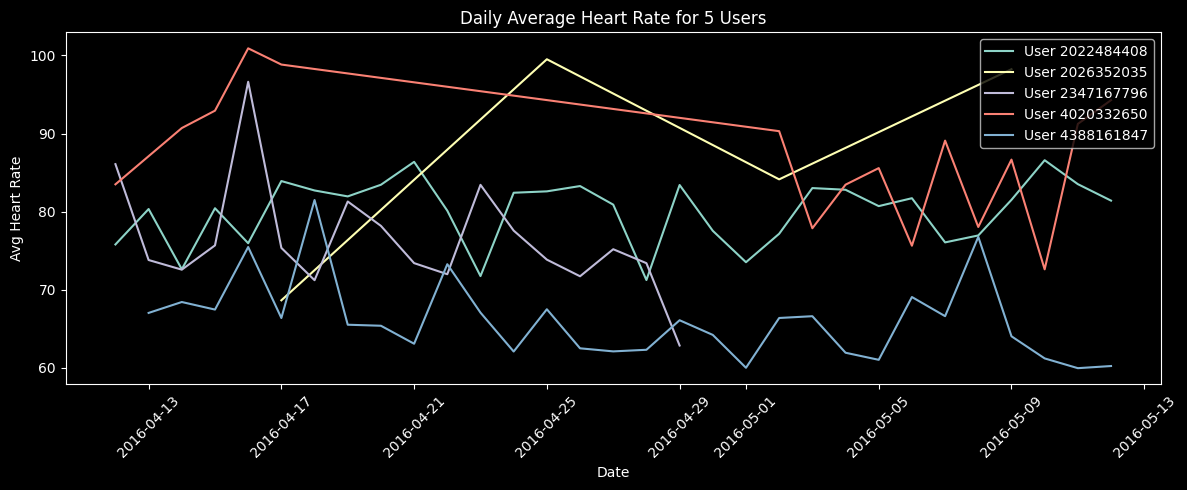

In [262]:
fig, ax = plt.subplots(figsize=(12, 5))

for uid in five_users:
    user_data = hr_daily[hr_daily["Id"] == uid]
    #print (user_data)
    ax.plot(user_data["Date"], user_data["AvgHeartRate"], label=f"User {uid}")

ax.set_title("Daily Average Heart Rate for 5 Users")
ax.set_xlabel("Date")
ax.set_ylabel("Avg Heart Rate")
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [140]:
# Part 1-d
weightLogInfo["Date"] = pd.to_datetime(weightLogInfo["Date"])

/var/folders/fm/1rc1d6s92qg_dtmxcn1__h1r0000gn/T/ipykernel_14240/3525667277.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weightLogInfo["Date"] = pd.to_datetime(weightLogInfo["Date"])


In [141]:
top_user = weightLogInfo["Id"].value_counts().idxmax()

In [142]:
user_weight = weightLogInfo[weightLogInfo["Id"] == top_user].sort_values("Date")

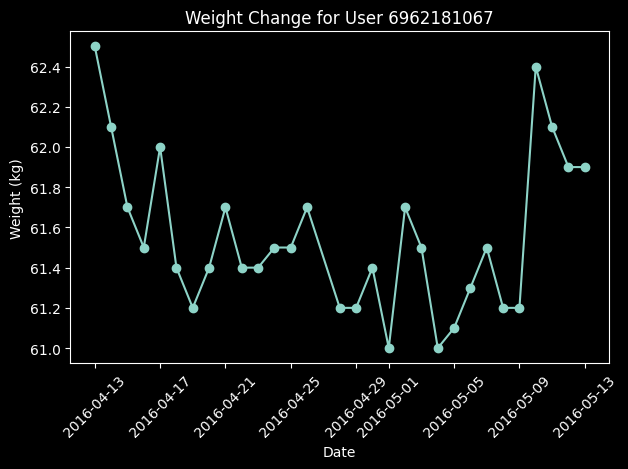

In [280]:
plt.plot(user_weight["Date"], user_weight["WeightKg"], marker='o')

plt.xlabel("Date")
plt.ylabel("Weight (kg)")
plt.title(f"Weight Change for User {top_user}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`Part 4 Statistical Testing`

In [355]:
print(merged.head())

           Id               SleepDay  TotalSleepRecords  TotalMinutesAsleep  \
0  1503960366  4/12/2016 12:00:00 AM                  1                 327   
1  1503960366  4/13/2016 12:00:00 AM                  2                 384   
2  1503960366  4/15/2016 12:00:00 AM                  1                 412   
3  1503960366  4/16/2016 12:00:00 AM                  2                 340   
4  1503960366  4/17/2016 12:00:00 AM                  1                 700   

   TotalTimeInBed        Date ActivityDate  TotalSteps  TotalDistance  \
0             346  2016-04-12    4/12/2016       13162           8.50   
1             407  2016-04-13    4/13/2016       10735           6.97   
2             442  2016-04-15    4/15/2016        9762           6.28   
3             367  2016-04-16    4/16/2016       12669           8.16   
4             712  2016-04-17    4/17/2016        9705           6.48   

   TrackerDistance  LoggedActivitiesDistance  VeryActiveDistance  \
0             8.50

In [387]:
merged_clean = merged[ (merged["Calories"] > 0) &
    (merged["VeryActiveMinutes"] > 0) &
    (merged["TotalMinutesAsleep"] > 0)
]

In [388]:
print(merged_clean.head())

           Id               SleepDay  TotalSleepRecords  TotalMinutesAsleep  \
0  1503960366  4/12/2016 12:00:00 AM                  1                 327   
1  1503960366  4/13/2016 12:00:00 AM                  2                 384   
2  1503960366  4/15/2016 12:00:00 AM                  1                 412   
3  1503960366  4/16/2016 12:00:00 AM                  2                 340   
4  1503960366  4/17/2016 12:00:00 AM                  1                 700   

   TotalTimeInBed        Date ActivityDate  TotalSteps  TotalDistance  \
0             346  2016-04-12    4/12/2016       13162           8.50   
1             407  2016-04-13    4/13/2016       10735           6.97   
2             442  2016-04-15    4/15/2016        9762           6.28   
3             367  2016-04-16    4/16/2016       12669           8.16   
4             712  2016-04-17    4/17/2016        9705           6.48   

   TrackerDistance  LoggedActivitiesDistance  VeryActiveDistance  \
0             8.50

In [389]:
median_active = merged_clean["VeryActiveMinutes"].median()
print(median_active)
high_active = merged_clean[merged_clean["VeryActiveMinutes"] > median_active]["Calories"]
low_active = merged_clean[merged_clean["VeryActiveMinutes"] <= median_active]["Calories"]

29.0


In [390]:
t1, p1 = st.ttest_ind(high_active, low_active)
print(f"VeryActiveMinutes → t={t1}, p={p1}")

VeryActiveMinutes → t=3.9523968017105418, p=9.939596566457025e-05


In [393]:
median_sleep = merged_clean["TotalMinutesAsleep"].median()
print(median_sleep)
high_sleep = merged_clean[merged_clean["TotalMinutesAsleep"] > median_sleep]["Calories"]
low_sleep = merged_clean[merged_clean["TotalMinutesAsleep"] <= median_sleep]["Calories"]

420.5


In [392]:
t2, p2 = st.ttest_ind(high_sleep, low_sleep)
print(f"TotalMinutesAsleep → t={t2}, p={p2}")

TotalMinutesAsleep → t=1.477392353919982, p=0.14076243415379538
